In [1]:
from scipy.cluster.hierarchy import ward, average, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform
from scipy import sparse
from sklearn.metrics import silhouette_score, silhouette_samples, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import scanpy as sc
import hdf5plugin
import numpy as np
import pandas as pd
from tqdm import tqdm
import importlib
import igraph
import anndata as ad

import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [2]:
perts = pd.read_csv("Data/Perts/KeggoRo_perts.pert",sep=" ")

In [22]:
i = 0
i_perts = perts[(perts["Index"]>=i+0) & (perts["Index"]<i+10)]
pgenes = i_perts["Gene"].unique()
pnames = ["_".join(list(list(i_perts.groupby("Index"))[j][1]["Gene"])) for j in range(10)]

In [23]:
pnames

['ETS2_TGFBR2',
 'MAP2K6_SPI1',
 'SNAI1',
 'KLF1',
 'KLF1_MAP2K6',
 'ZNF318',
 'SGK1_TBX3',
 'HNF4A',
 'CEBPA_CEBPB',
 'PTPN1']

In [ ]:
pert_adata = sc.read_h5ad(f"Data/Projects/KeggoRo/perturb_norm_pert.h5ad")

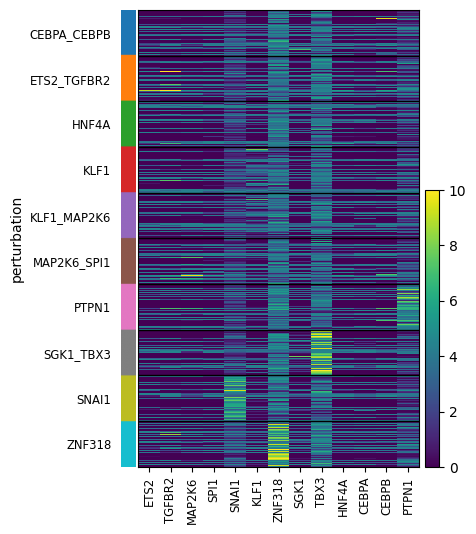

In [ ]:
sc.pl.heatmap(pert_adata,pgenes,groupby='perturbation',show_gene_labels=True,vmax=10,layer="log1p")

In [14]:
norman_data = sc.read_h5ad(f"Data/Experimental/Norman19/perturb_norm.h5ad")
norman_data.obs["perturbation"]=["_".join(sorted(pert.split("_"))) for pert in norman_data.obs["perturbation"]]

/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/anndata/_core/anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


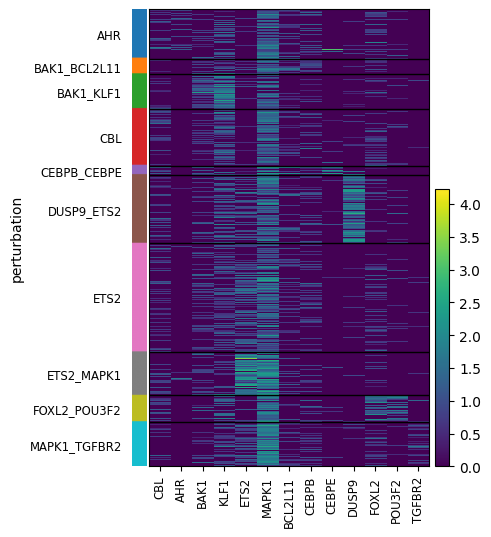

In [38]:
sc.pl.heatmap(norman_data[norman_data.obs["perturbation"].isin(pnames)],pgenes,groupby="perturbation",layer="log1p")

In [72]:
rep_data = sc.read_h5ad(f"Data/Experimental/Replogle22/perturb_norm.h5ad")

In [73]:
sc.tl.rank_genes_groups(rep_data,groupby="perturbation",reference="ctrl",layer="log1p",method="t-test_overestim_var")

/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarning: Da

In [32]:
sc.tl.rank_genes_groups(norman_data,groupby="perturbation",reference="ctrl",layer="log1p",method="t-test_overestim_var")

/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarning: Da

In [88]:
range(75,np.max(perts[perts["Type"]==2]["Index"]))

range(75, 133)

In [84]:
    pnames_all = ["_".join(list(list(perts[perts["Type"]==2].groupby("Index"))[j][1]["Gene"])) for j in range(np.max(perts[perts["Type"]==2]["Index"]))]


IndexError: list index out of range

In [115]:
perts

,Index,Gene,Type
0,0,CEBPB,1
1,0,CEBPE,1
2,1,MAPK1,1
3,1,TGFBR2,1
4,2,TGFBR2,1
...,...,...,...
166,129,RAC1,2
167,130,GABPA,2
168,131,PPP1CA,2
169,132,SAMM50,2


In [114]:
rep_data

AnnData object with n_obs × n_vars = 33752 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo', 'cell_type', 'condition', 'condition_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells', 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_

In [122]:
perts["Gene"].find(["UBL5"])

AttributeError: 'Series' object has no attribute 'find'

In [128]:
datasets

[AnnData object with n_obs × n_vars = 97120 × 33694
     obs: 'guide_id', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'cell_type', 'condition', 'condition_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
     var: 'ensemble_id', 'ncounts', 'ncells', 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     uns: 'log1p', 'rank_genes_groups'
     layers: 'log1p', 'normalized',
 AnnData object with

11.885457


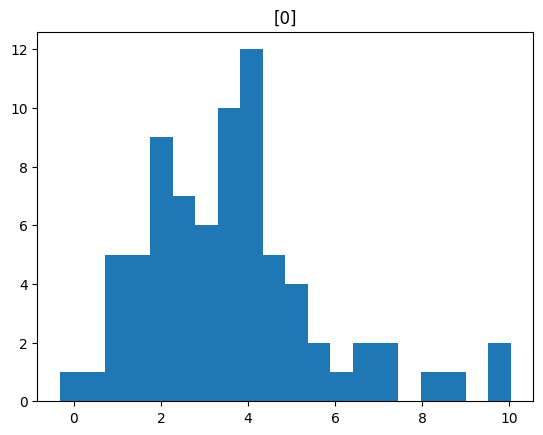

6.0908704


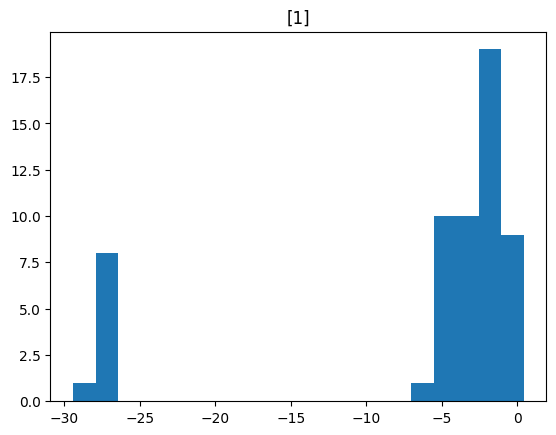

In [134]:
last_max = -1
for k in range(len(datasets)):
    logfc = []
    pnames_all = ["_".join(list(list(perts.groupby("Index"))[j][1]["Gene"])) for j in range(last_max+1,1+np.max(perts[perts["Type"]==k+1]["Index"]))]
    last_max = np.max(perts[perts["Type"]==k+1]["Index"])
    for pname in pnames_all:
        psplit = pname.split("_")
        #print(psplit)
        logfc_pname = []
        for ps in psplit:
            try:
                pos = np.where(datasets[k].uns["rank_genes_groups"]["names"][pname]==ps)
            except:
                print(ps)
                continue
            logfc_pname.append(datasets[k].uns["rank_genes_groups"]["logfoldchanges"][pname][pos])
        logfc.append(np.mean(logfc_pname))
    print(2**np.abs(np.median(logfc)))
    plt.hist(logfc,bins=20)
    plt.title([k])
    plt.show()
    


In [2]:
import matplotlib as mpl
importlib.reload(mpl)
mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 14,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 14,            # axis-label size matches body text
    'xtick.labelsize'     : 9,             # tick labels one point smaller
    'ytick.labelsize'     : 9,
    'legend.fontsize'     : 11,             # legend text one point smaller
    'figure.titlesize'    : 20,
    
    #'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
    #    '#0072B2', '#D55E00', '#009E73',
    #    '#E69F00', '#CC79A7', '#56B4E9',
    #]),
    
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    'xtick.minor.size'    : 2,             # half of major — proportional
    'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 300,           # publication-quality resolution
})

prop_cycle = [c["color"] for c in list(mpl.rcParams["axes.prop_cycle"])]

In [3]:
import importlib
import pgrins_narrow_params
from Prep_Data import pgrins_prepare_output
importlib.reload(pgrins_narrow_params)

<module 'pgrins_narrow_params' from '/home/mi/sommereg03/bsc_thesis_pGRiNS/pgrins_narrow_params.py'>

In [4]:
sc.settings.verbosity = 0

# Set figure parameters for clean, minimal plots
sc.settings.set_figure_params(figsize=(10,10),dpi=80, facecolor="white", frameon=False)

/tmp/ipykernel_897263/2009699256.py:4: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(figsize=(10,10),dpi=80, facecolor="white", frameon=False)


In [12]:
grins_data = sc.read_h5ad("Data/Projects/Keggoro/perturb_norm_ctrl.h5ad")

In [16]:
grins_data.X

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 400375392 stored elements and shape (100000, 9471)>

In [8]:
common_genes = list(set(adata.var_names) & set(grins_data.var_names))
grins_data = grins_data[grins_data.obs["perturbation"]=="ctrl"][:,common_genes]
adata = adata[adata.obs["perturbation"]=="ctrl"][:,common_genes]
#grins_matrix = grins_data.layers["log1p"].todense()
#adata_matrix = adata.layers["log1p"].todense()

In [8]:
candidate_mask = pgrins_narrow_params.get_candidate_cells(grins_matrix,adata_matrix,times_dev=20,candidate_limit=None)

Getting MSE scores for adata...


100%|██████████| 10598/10598 [00:03<00:00, 2654.35it/s]


Getting MSE scores for GRiNS...


100%|██████████| 100000/100000 [00:21<00:00, 4710.90it/s]


Getting candidate cells...
24.795% (24795) of cells were kept.


In [9]:
grins_data = grins_data[candidate_mask]

In [9]:
sc.pp.pca(grins_data, svd_solver="arpack",layer="missing_log1p")

/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


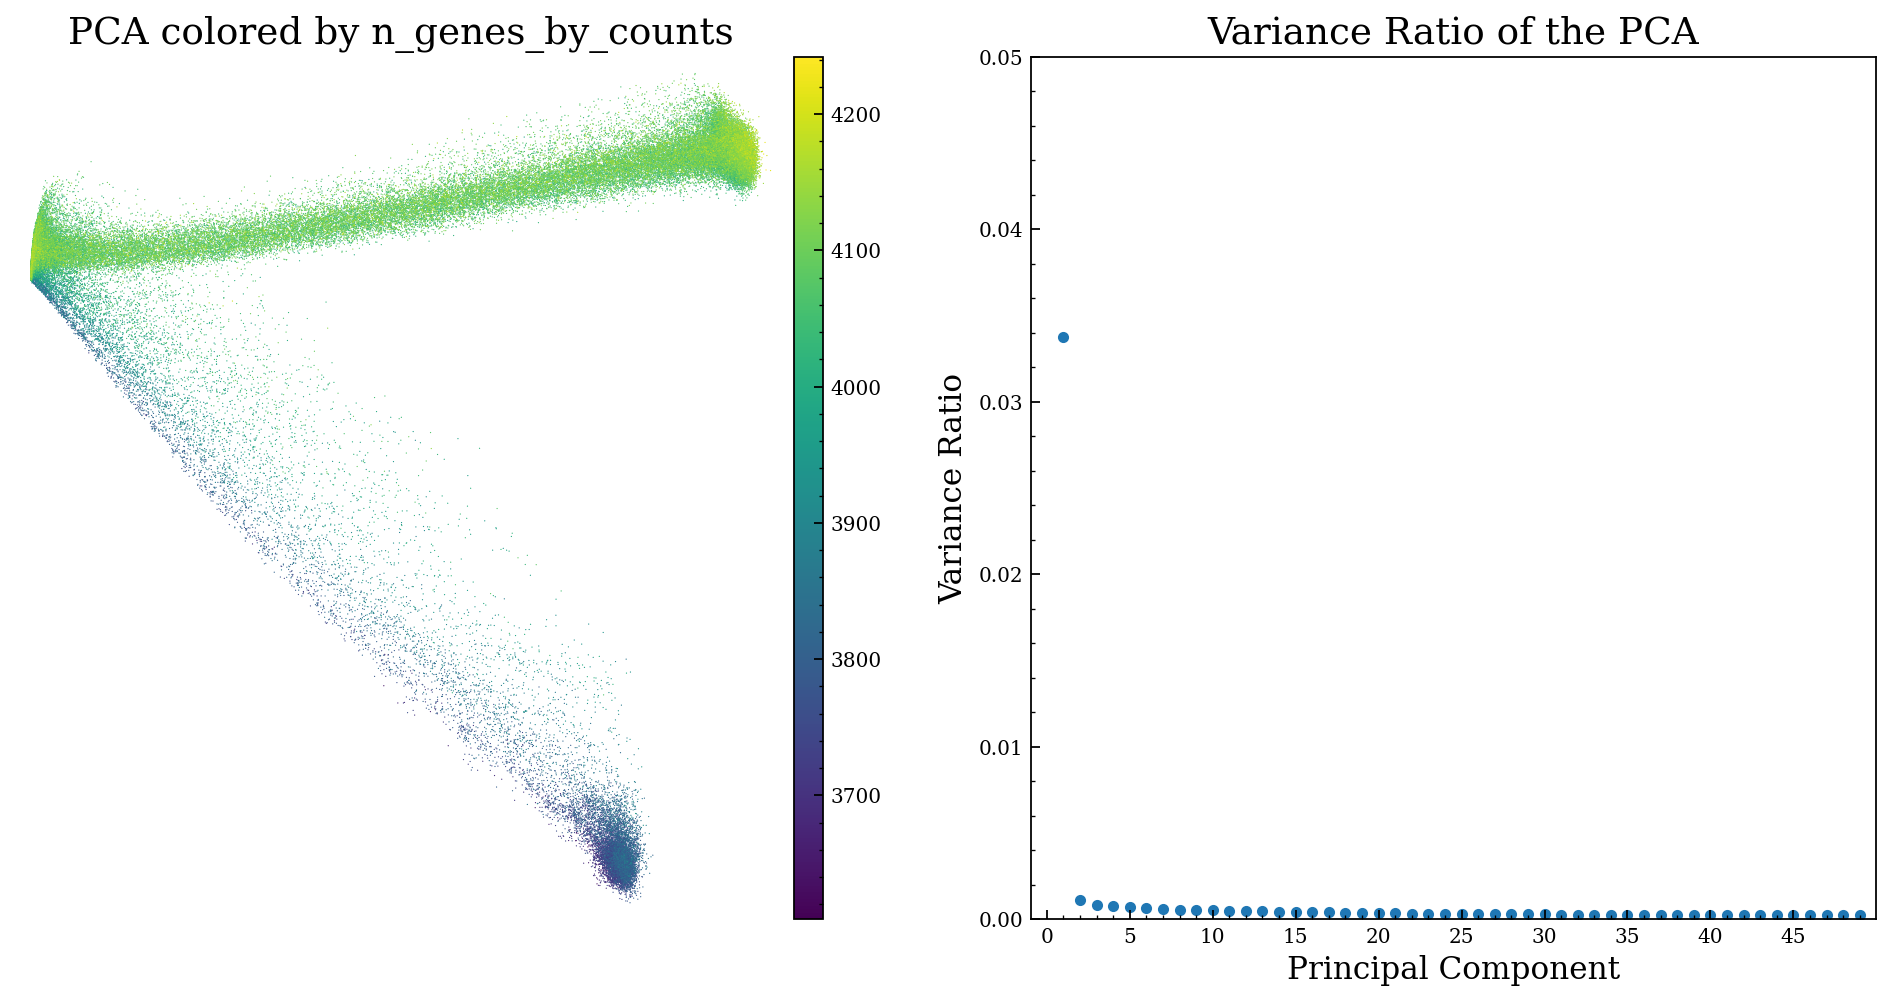

In [73]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
max_pca = 50
axs[1].scatter(range(max_pca),grins_data.uns["pca"]["variance_ratio"][:max_pca])
axs[1].set_xlabel("Principal Component")
axs[1].set_ylabel("Variance Ratio")
axs[1].set_xticks(range(0,max_pca,5))
axs[1].set_ylim(0,0.05)
axs[1].set_title("Variance Ratio of the PCA")
sc.pl.pca(grins_data,color="n_genes_by_counts",layer="log1p",ax=axs[0],title="PCA colored by n_genes_by_counts")
plt.show()

In [129]:
cum_pca = np.cumsum(grins_data.uns["pca"]["variance_ratio"])
redundant_pcs = np.where(np.array([cum_pca[i+1]/cum_pca[i] for i in range(len(cum_pca)-1)])<1.01)[0] # Find the PC where the increase in the cumulative elbow plot is less than 1%
if len(redundant_pcs)==0:
    n_pcs = len(cum_pca)
else:
    n_pcs = max(10,redundant_pcs[0])

In [130]:
sc.pp.neighbors(grins_data,use_rep="X_pca",n_pcs=n_pcs)

In [131]:
sc.tl.umap(grins_data)

/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


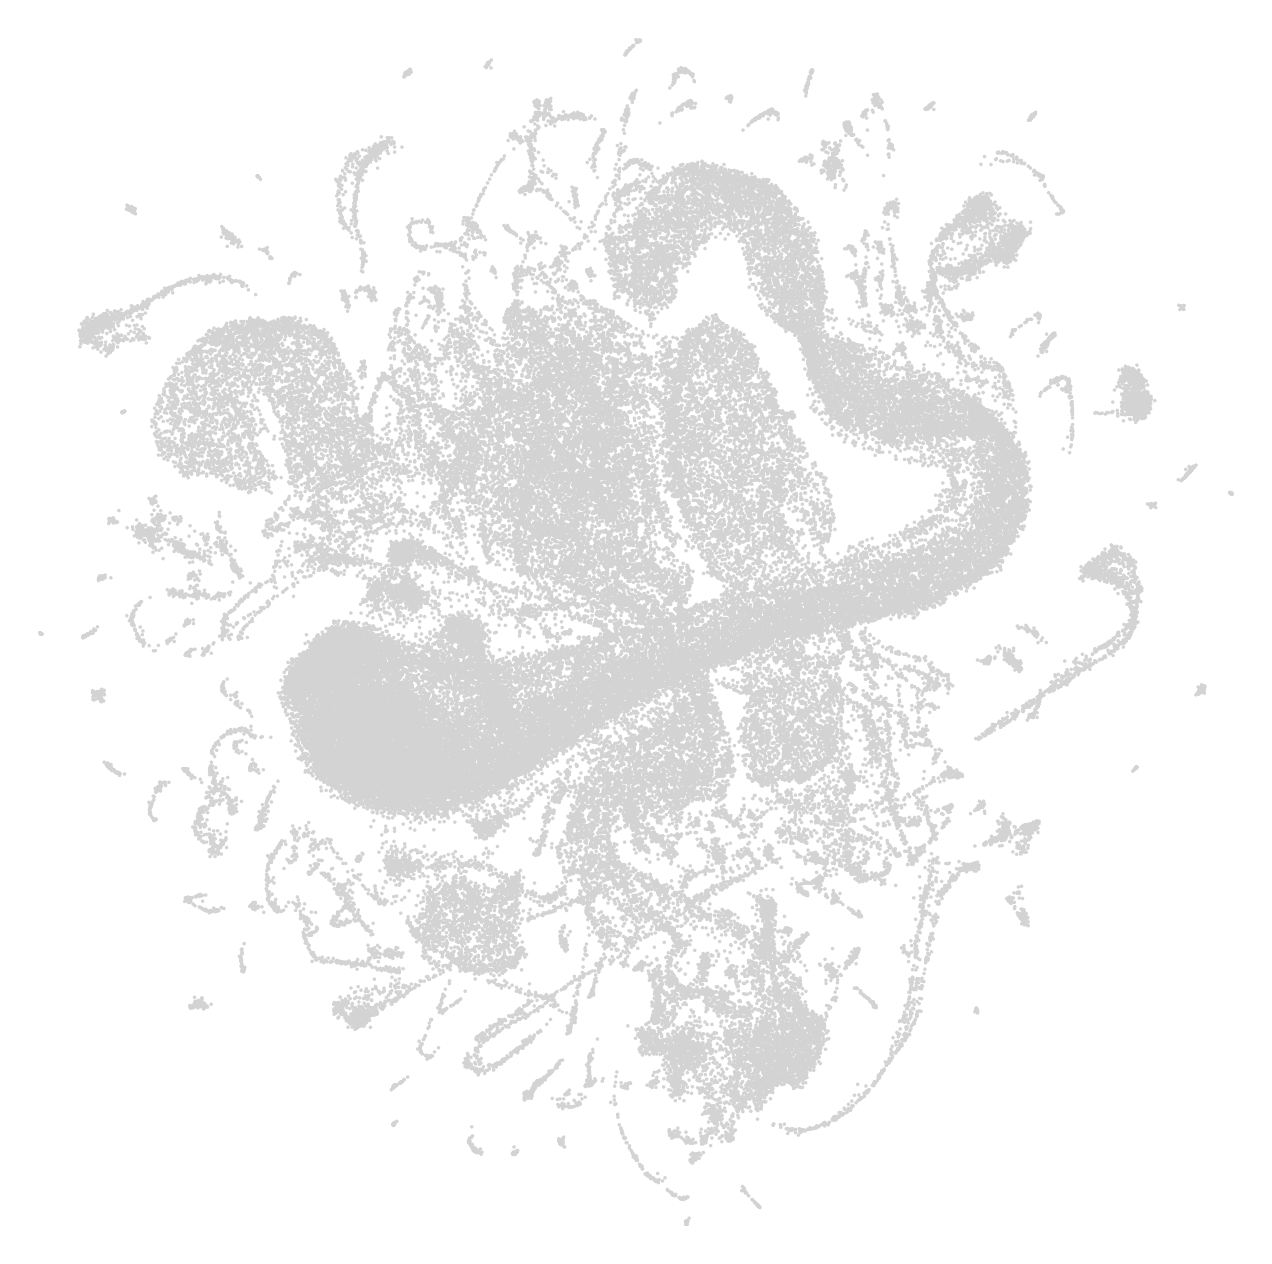

In [132]:
sc.pl.umap(grins_data,s=10)

In [93]:
sc.tl.leiden(grins_data, flavor="igraph")

In [94]:
cluster_labels = grins_data.obs["leiden"]
cluster_counts = cluster_labels.value_counts()
clusters = np.array(list(cluster_counts.keys()))

In [95]:
sample_silhouette_values = silhouette_samples(grins_data.obsm["X_umap"], cluster_labels)
silhouette_avg = np.mean(sample_silhouette_values)

In [100]:
# No candidates:
best_clusters = np.array(list(cluster_counts[cluster_counts>grins_data.shape[0]*0.01].keys())) # At least 1% of total cells in cluster
best_clusters = clusters[np.argsort([np.mean(sample_silhouette_values[cluster_labels==c]) for c in best_clusters])[::-1][:10]] # 10 clusters with highest silhouette score
best_cluster_size = sum([cluster_counts[c] for c in best_clusters])

In [101]:
best_clusters

array(['150', '134', '120', '111', '117', '115', '56', '110', '116',
       '121'], dtype='<U3')

In [99]:
# Candidates:
last_cluster = 1+np.max([1,np.argmax(np.array([cluster_counts[i]/cluster_counts[i+1] for i in range(len(cluster_counts)-1)]))]) # Look at at least 2 clusters
best_clusters = cluster_counts[:last_cluster].index.values
best_clusters = [c for c in best_clusters if cluster_counts[c]>10] # Remove clusters with <10 cells
best_cluster_size = sum(cluster_counts[:last_cluster+1])

/tmp/ipykernel_897263/1625873687.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_cluster = 1+np.max([1,np.argmax(np.array([cluster_counts[i]/cluster_counts[i+1] for i in range(len(cluster_counts)-1)]))]) # Look at at least 2 clusters


100%|██████████| 159/159 [00:00<00:00, 2743.53it/s]

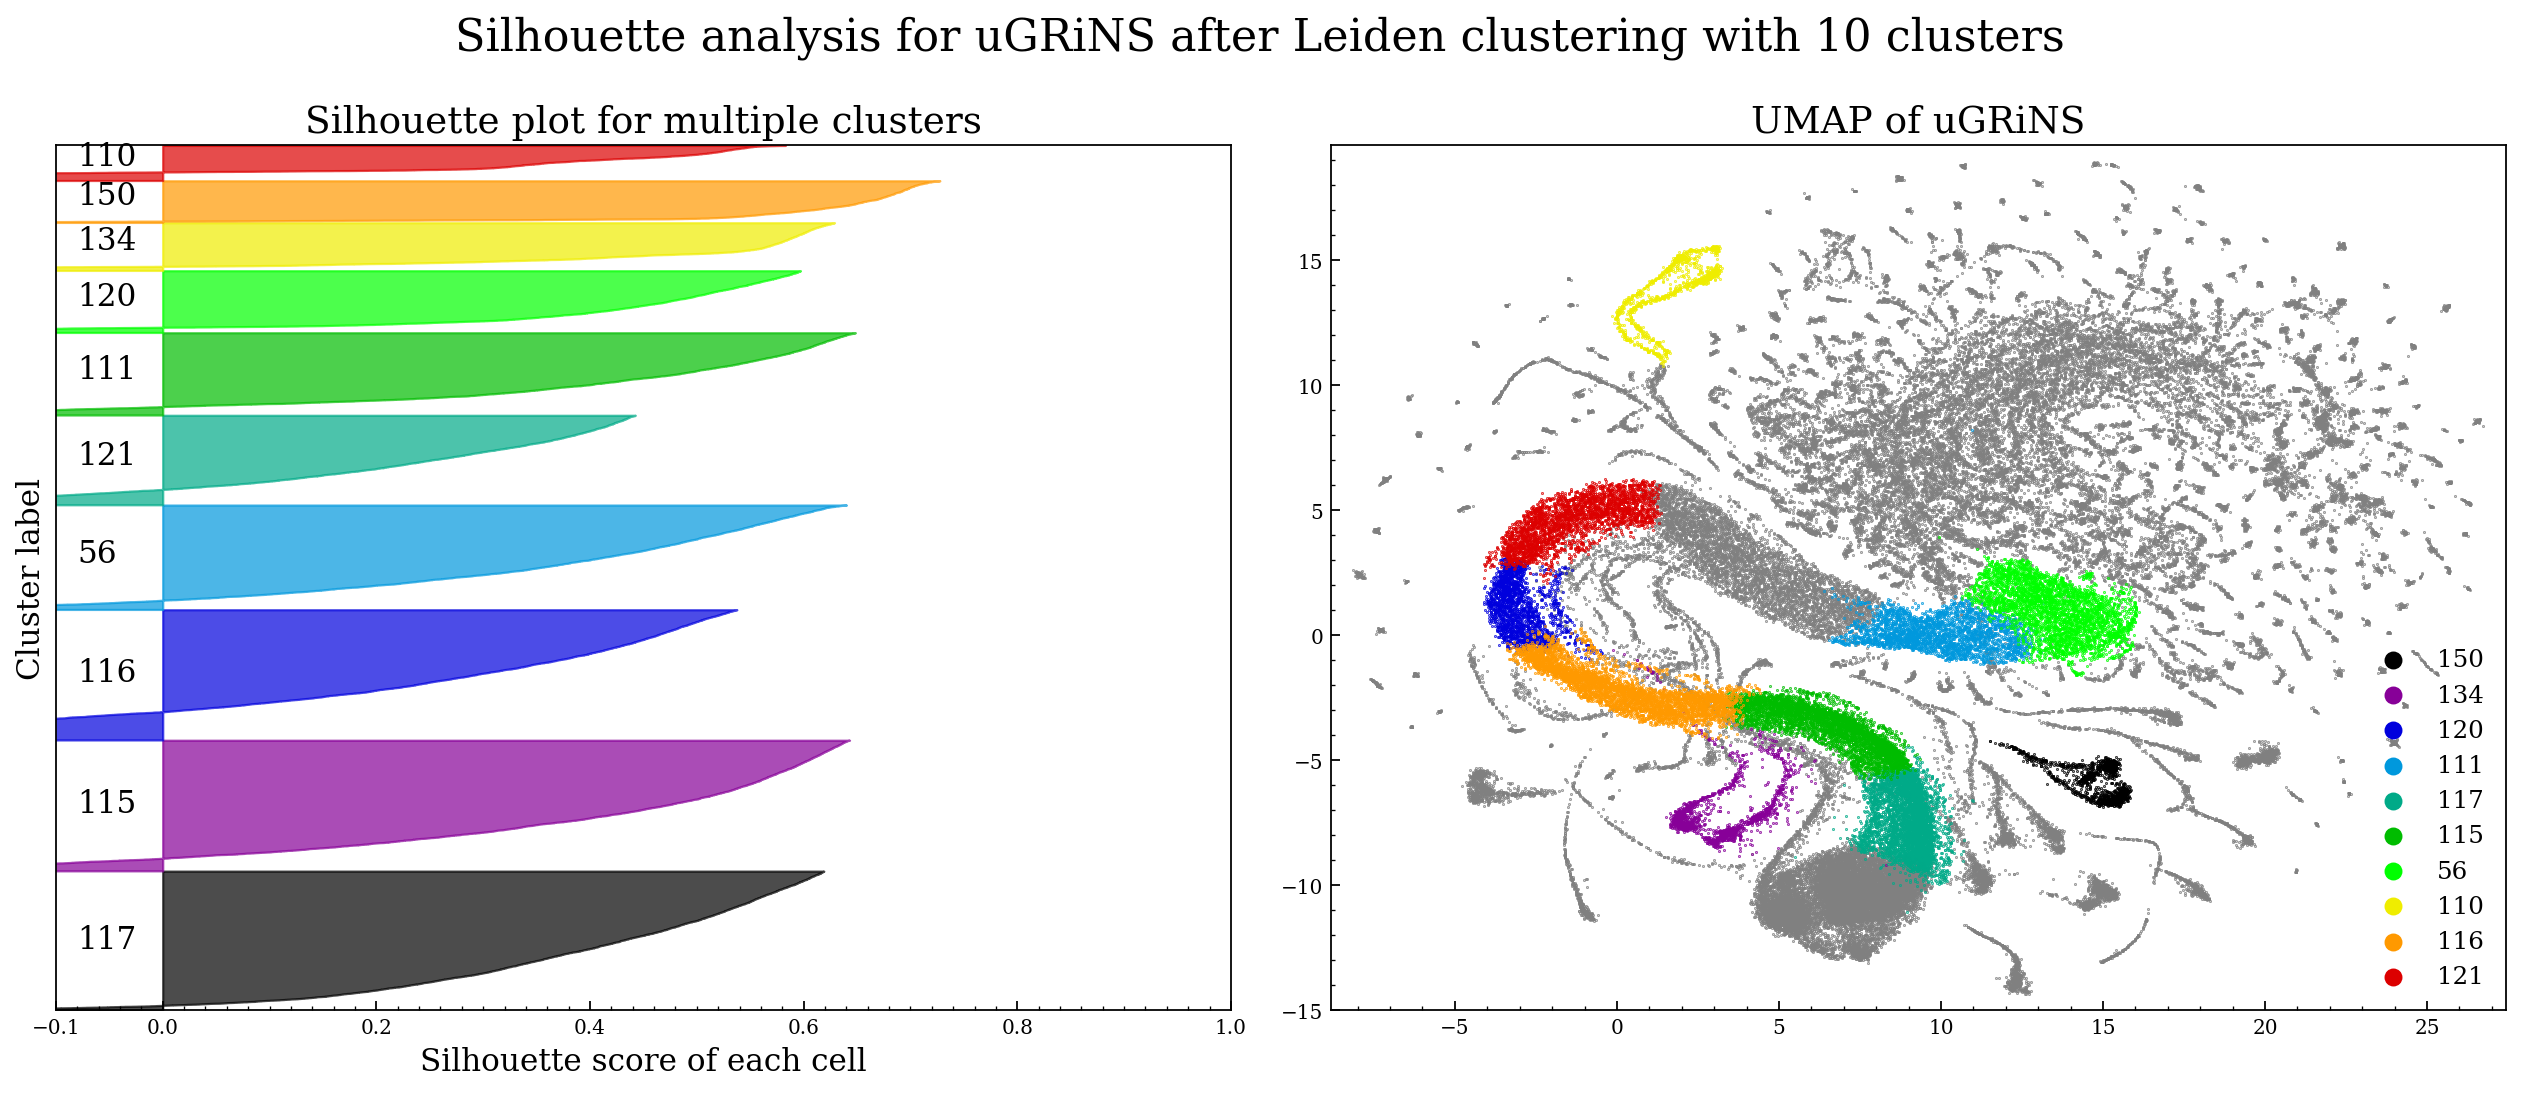

In [128]:
n_clusters = len(best_clusters)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(16, 7)

ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, best_cluster_size + (n_clusters + 1) * 10])

y_lower = 10
cluster_sil_means = []
best_cluster_i = -1

for i in tqdm(range(len(clusters))):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    if clusters[i] not in best_clusters:
        continue
    else:
        best_cluster_i += 1
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == clusters[i]]

    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(best_cluster_i) / n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.08, y_lower + 0.45 * size_cluster_i, str(clusters[i]))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("Silhouette plot for multiple clusters")
ax1.set_xlabel("Silhouette score of each cell")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
#ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
"""
ax2.scatter(
    X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
)
"""
ax2.scatter(grins_data.obsm["X_umap"].T[0][~cluster_labels.isin(best_clusters)],grins_data.obsm["X_umap"].T[1][~cluster_labels.isin(best_clusters)],s=0.1,c="grey")
for i in range(len(best_clusters)):
    ax2.scatter(grins_data.obsm["X_umap"].T[0][cluster_labels==best_clusters[i]],grins_data.obsm["X_umap"].T[1][cluster_labels==best_clusters[i]],s=0.1,c = matplotlib.colors.to_hex(cm.nipy_spectral(float(i) / n_clusters)),label=best_clusters[i])    

lgnd = ax2.legend()
for handle in lgnd.legend_handles:
    handle.set_sizes([50])
ax2.set_title("UMAP of uGRiNS")

plt.suptitle(
    "Silhouette analysis for uGRiNS after Leiden clustering with %d clusters"
    % n_clusters
)
plt.tight_layout()
plt.show()

In [135]:
adata_mean = np.asarray(np.mean(adata.layers["log1p"],axis=0))
mses = []
sil_means = []

for cluster in best_clusters:
    mses.append(mean_squared_error(np.asarray(np.mean(grins_data[cluster_labels==cluster].layers["missing_log1p"],axis=0)),adata_mean))
    sil_means.append(np.mean(sample_silhouette_values[cluster_labels == cluster]))
mses, sil_means, best_clusters

([7.716952727784546,
  7.4764495800684845,
  2.1814918400290435,
  0.30071538435567474,
  7.25240701656218,
  5.539543781306979,
  0.3080100545035201,
  6.069757030666325,
  3.4799150677519117,
  1.3388049334242853],
 [np.float32(0.5989514),
  np.float32(0.43776247),
  np.float32(0.39825067),
  np.float32(0.39696786),
  np.float32(0.39320543),
  np.float32(0.38511032),
  np.float32(0.35416716),
  np.float32(0.23494676),
  np.float32(0.20955698),
  np.float32(0.20528364)],
 array(['150', '134', '120', '111', '117', '115', '56', '110', '116',
        '121'], dtype='<U3'))

In [104]:
# No candidates:
control_cluster_id = np.argmin(mses)

In [28]:
# Candidates:
control_cluster_id = np.argmin(np.argsort(np.argsort(sil_means)[::-1])+np.argsort(np.argsort(mses))) # np.argsort(np.argsort(x)) returns the ranking of each entry
                                                                                # Find the cluster with the highest silhouette score and lowest MSE (additive)

In [ ]:
control_cluster = best_clusters[np.argmin(mses)]
final_grins = grins_data[cluster_labels==control_cluster]
final_grins

View of AnnData object with n_obs × n_vars = 3802 × 9327
    obs: 'PertNum', 'InitCondNum', 'ParamNum', 'perturbation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'log1p', 'missing_matrix', 'missing_log1p'
    obsp: 'distances', 'connectivities'

In [48]:
ic_param_pairs = np.array([cell.split("_")[1:] for cell in list(final_grins.obs_names)],dtype=int).T

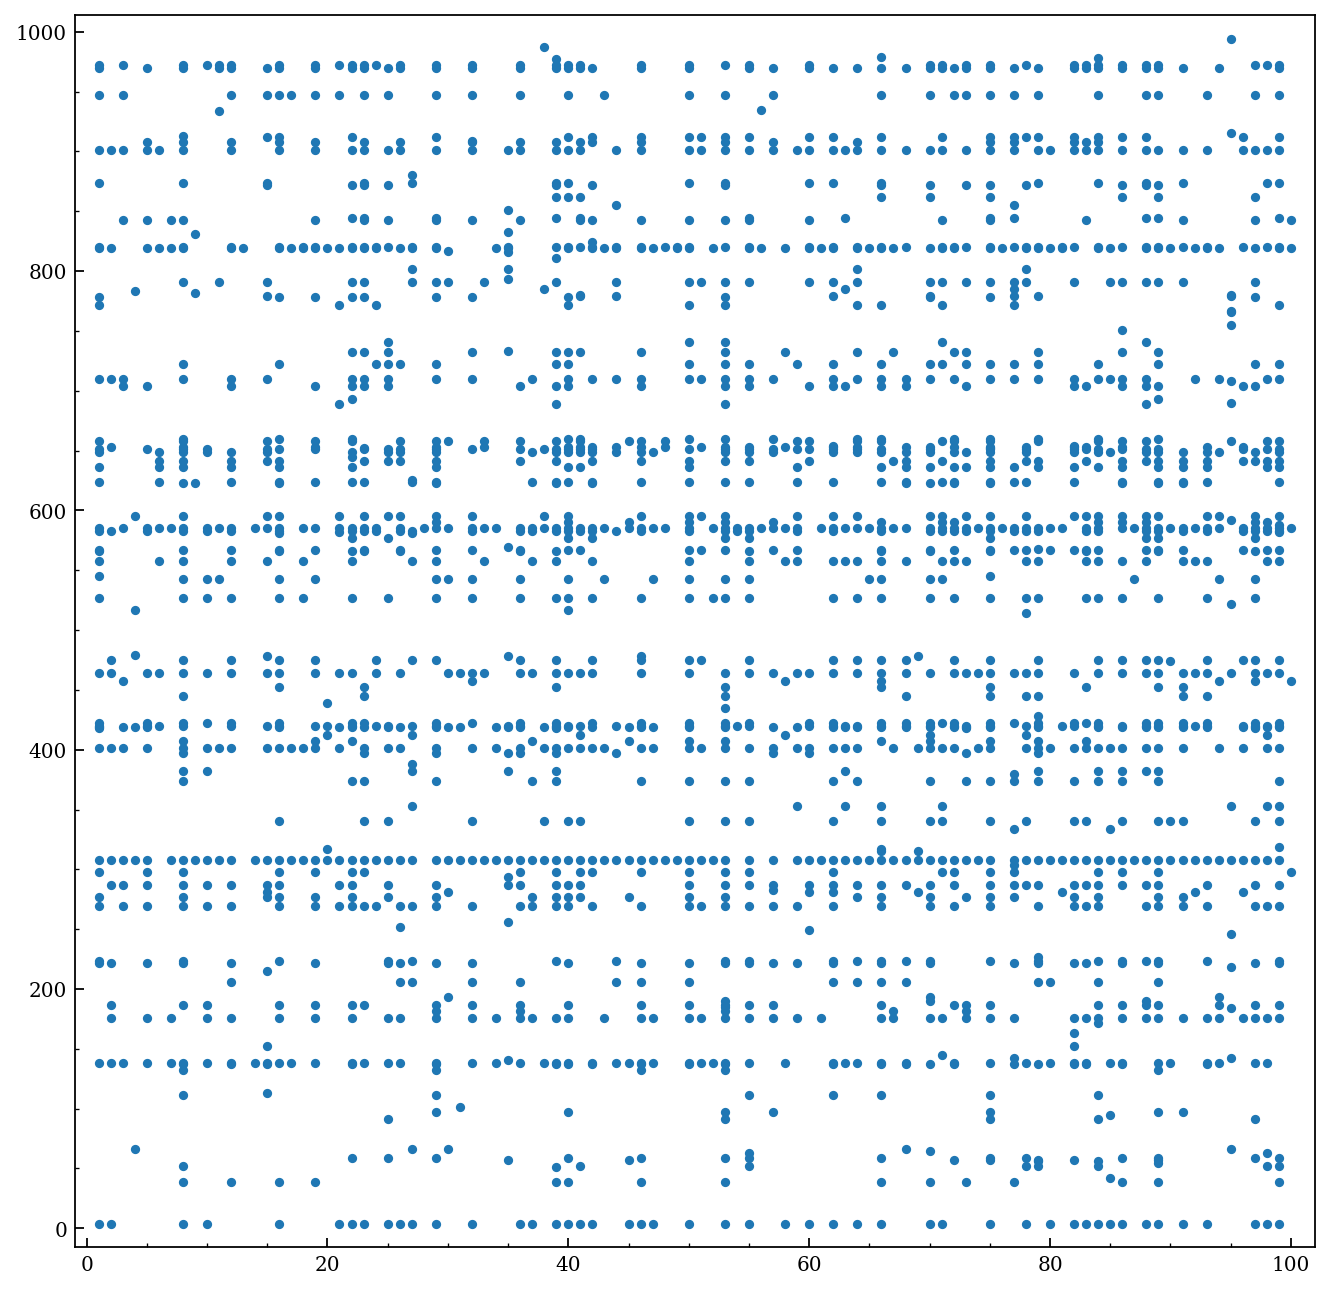

In [49]:
plt.scatter(ic_param_pairs[0],ic_param_pairs[1],s=10)
plt.show()

In [117]:
param_u, param_c = np.unique(ic_param_pairs[1],return_counts=True)
ic_u, ic_c = np.unique(ic_param_pairs[0],return_counts=True)

# Old clustering:

In [4]:
csr_indices = test["Cluster_Metrics"].nonzero()

In [16]:
csize = [sum(test["Clusterings"][csr_indices[0][i]]==csr_indices[1][i]) for i in tqdm(range(len(csr_indices[0])))]
cscore = test["Cluster_Metrics"].data

  0%|          | 53/2386930 [00:00<1:15:35, 526.31it/s]

100%|██████████| 2386930/2386930 [49:17<00:00, 807.16it/s]


In [34]:
pd.DataFrame({"Test":test["Clusterings"][0]})

,Test
0,1162
1,9084
2,7471
3,4258
4,1057
...,...
9995,2662
9996,8015
9997,8209
9998,2067


In [ ]:
pd.DataFrame({"Cluster":test["Clusterings"][9990]}).groupby(by="Cluster").indices

{np.int32(1): array([   0,    4,    9, ..., 9995, 9998, 9999], shape=(4120,)),
 np.int32(2): array([   1,    2,    3, ..., 9994, 9996, 9997], shape=(5880,))}

In [ ]:
# Idea: split grins_matrix only once based on clustering

(0.0, 200.0)

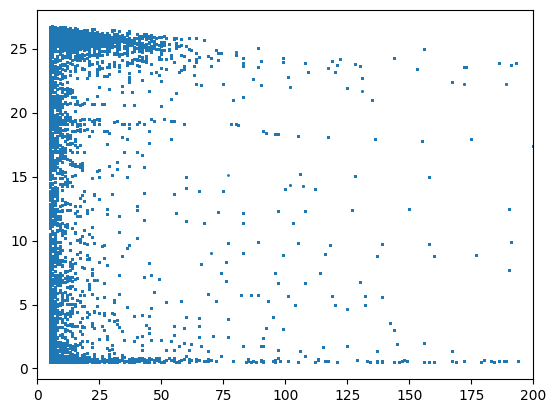

In [41]:
plt.scatter(csize,cscore,s=1)
plt.xlim(0,200)

In [53]:
test["Best_Cluster"]

[np.int64(8026), np.int32(2)]

In [55]:
tgmatrix = grins_matrix[test["Clusterings"][test["Best_Cluster"][0]]==test["Best_Cluster"][1]]
tgmean = np.mean(tgmatrix,axis=0)

In [51]:
tgmatrix.shape

(381, 4022)

In [6]:
adata=adata[:,adata.var["pct_dropout_by_counts"]<90]
grins_data=grins_data[:,grins_data.var["pct_dropout_by_counts"]<90]
#grins_data.obs["perturbation"]="ctrl"
if adata is not None: # if not none: find common genes again
    print("Subsetting datasets")
    common_genes = list(set(adata.var_names) & set(grins_data.var_names) )#& set(rep_data.var_names))
    grins_matrix = grins_data[grins_data.obs["perturbation"]=="ctrl"][:,common_genes].layers["log1p"].todense()
    adata_matrix = adata[adata.obs["perturbation"]=="ctrl"][:,common_genes].layers["log1p"].todense()
    #rep_matrix = rep_data[rep_data.obs["perturbation"]=="ctrl"][:,common_genes].layers["log1p"].todense()

Subsetting datasets


In [7]:
adata_mean = np.mean(adata_matrix,axis=0)
grins_mean = np.mean(grins_matrix,axis=0)
#rep_mean = np.mean(rep_matrix,axis=0)

In [8]:
import importlib
import pgrins_narrow_params

In [127]:
importlib.reload(pgrins_narrow_params)

<module 'pgrins_narrow_params' from '/home/mi/sommereg03/bsc_thesis_pGRiNS/pgrins_narrow_params.py'>

In [154]:
candidate_cell_mask = pgrins_narrow_params.get_candidate_cells(grins_matrix,adata_matrix,times_dev=10)

Getting MSE scores for adata...


100%|██████████| 10598/10598 [00:02<00:00, 3769.72it/s]


Getting MSE scores for GRiNS...


100%|██████████| 100000/100000 [00:17<00:00, 5644.82it/s]


Getting candidate cells...
3.334% (3334) of cells were kept.


In [156]:
ic_param_pairs = np.array([cell.split("_")[1:] for cell in list(grins_data[candidate_cell_mask].obs_names)],dtype=int).T

In [157]:
ic_param_pairs[1]

array([ 57,  72,  75, ..., 890, 909, 935], shape=(3334,))

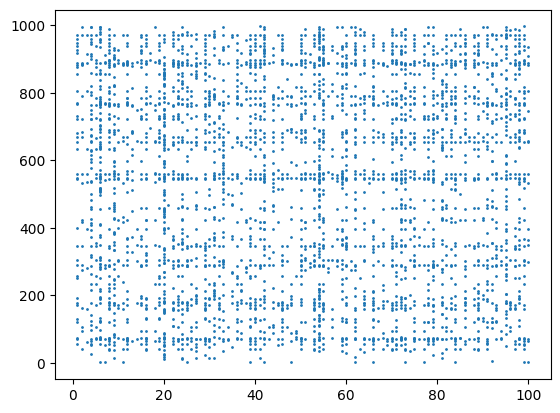

In [175]:
plt.scatter(ic_param_pairs[0],ic_param_pairs[1],s=1) # Some params appear together with many ICs and vice versa -> in that case, the param is always good

In [176]:
param_u, param_c = np.unique(ic_param_pairs[1],return_counts=True)

In [225]:
params = pd.read_parquet("Data/SimulResults_Racipe/Keggoro/001/Keggoro_params_001_sinks_ctrl.parquet").iloc[:,:-1]

In [180]:
ics = pd.read_parquet("Data/SimulResults_Racipe/Keggoro/001/Keggoro_init_conds_001_ctrl.parquet").iloc[:,:-1]

In [177]:
candidate_params = params.iloc[param_u[param_c>25]]

In [226]:
params

,Prod_A2ML1,Prod_AAK1,Prod_AATBC,Prod_AATK,Prod_ABALON,Prod_ABAT,Prod_ABCA10,Prod_ABCA13,Prod_ABCA2,Prod_ABCA4,...,Hill_ZNF207_ZZEF1,ActFld_ZNF584_ZZEF1,Thr_ZNF584_ZZEF1,Hill_ZNF584_ZZEF1,ActFld_ZNF766_ZZEF1,Thr_ZNF766_ZZEF1,Hill_ZNF766_ZZEF1,ActFld_ZNF83_ZZEF1,Thr_ZNF83_ZZEF1,Hill_ZNF83_ZZEF1
0,96.840762,48.905009,89.996327,48.596122,13.498473,52.184859,21.476184,79.747348,16.937043,75.180091,...,5.0,5.172207,27.797924,5.0,3.739532,170.155240,4.0,63.460318,127.647049,1.0
1,36.216185,84.341571,17.076819,35.925444,60.615009,58.660527,64.263926,29.655370,71.204633,59.184915,...,3.0,15.674443,140.095533,3.0,94.281810,17.198563,3.0,18.093704,144.652379,1.0
2,87.545567,2.922161,97.468336,3.062391,87.946926,86.701461,15.350376,94.651926,51.040300,2.207729,...,5.0,26.519144,138.188790,5.0,82.019779,27.727431,5.0,22.223557,94.132468,4.0
3,41.447318,26.983474,88.565988,94.713891,47.496590,14.794656,14.523542,42.310674,80.270949,62.550228,...,5.0,75.278725,50.270479,2.0,89.643582,171.929195,4.0,18.130038,34.808192,5.0
4,46.310173,35.968963,21.091601,53.110310,48.553618,64.244359,81.732276,75.482158,31.818490,38.879257,...,2.0,22.917937,16.159821,2.0,63.445916,129.460584,4.0,29.103222,158.397871,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,83.584019,53.045650,58.682424,90.273800,90.425944,48.010779,16.435328,24.434396,34.331923,93.513130,...,1.0,52.529524,85.471859,5.0,90.725903,104.472087,3.0,37.547212,93.966893,1.0
996,96.160243,90.020451,9.267654,48.322281,37.337052,86.151806,64.983431,62.571503,98.977440,72.239645,...,2.0,72.435640,87.173221,5.0,30.893006,146.548967,4.0,93.250266,21.746199,6.0
997,57.942368,13.242694,30.944338,16.843358,87.816941,28.435072,58.374042,46.592979,47.763880,12.618981,...,5.0,43.852133,6.791294,1.0,96.028039,73.931603,2.0,60.178588,47.246049,2.0
998,77.941517,59.993519,4.393844,67.781189,80.465974,4.241033,36.552272,67.126702,58.525622,12.532505,...,5.0,3.832747,120.160899,2.0,21.503154,140.884628,4.0,26.543967,59.940376,1.0


In [178]:
candidate_params

,Prod_A2M,Prod_ABCA1,Prod_ABL1,Prod_ACACB,Prod_ACE,Prod_ACE2,Prod_ACHE,Prod_ACP1,Prod_ACTB,Prod_ACTC1,...,Hill_RSPO1_ZNRF3,ActFld_ZNF175_ZNRF3,Thr_ZNF175_ZNRF3,Hill_ZNF175_ZNRF3,ActFld_ZBTB33_ZZZ3,Thr_ZBTB33_ZZZ3,Hill_ZBTB33_ZZZ3,InhFld_ZNF639_ZZZ3,Thr_ZNF639_ZZZ3,Hill_ZNF639_ZZZ3
42,53.942760,813769.669973,6.465676e+06,9240.516284,4.855279e+06,96.810307,21.472561,42.675006,-3.556261e+20,1952.168392,...,3.0,38.160388,2.886558,3.0,63.956756,35.918701,3.0,0.046508,5.994107,6.0
57,677.655324,205294.158990,4.689047e+06,7464.281869,2.633046e+06,21.276389,47.730202,54.270094,-3.939404e+20,8919.733454,...,4.0,64.472045,0.640909,2.0,41.514343,12.051467,1.0,0.014293,141.480831,5.0
66,491.230630,526396.648202,7.941055e+06,4321.856158,6.075393e+06,76.463387,96.819249,71.851584,-6.074003e+19,5328.925195,...,4.0,30.902315,0.678899,5.0,2.178291,12.726481,1.0,0.203805,57.713186,5.0
71,110.484682,593508.006761,5.713447e+06,6761.944574,9.774072e+06,24.545862,6.118415,67.998745,-9.669133e+19,7492.542255,...,2.0,17.037807,1.098482,6.0,6.416590,58.782547,2.0,0.070541,32.579578,3.0
72,969.197245,610581.500686,3.787671e+06,911.502513,9.310734e+06,29.757345,41.277034,87.517704,-4.546583e+20,1609.430434,...,2.0,46.550962,3.469915,2.0,50.553352,34.459846,3.0,0.010640,160.010559,2.0
75,211.800634,233315.002945,7.669667e+06,4550.365109,5.104571e+06,46.280436,64.179666,1.000000,-4.129218e+20,7837.425637,...,4.0,22.223198,1.863135,4.0,22.456798,17.566601,2.0,0.096998,104.702414,2.0
163,33.767497,931261.144695,4.516668e+06,3621.272925,3.837815e+06,45.328139,33.282130,92.604158,-7.144904e+19,507.280825,...,4.0,80.255150,4.091321,6.0,94.959535,24.912566,2.0,0.011814,103.565579,2.0
170,871.067356,775086.335897,3.192426e+05,4306.848758,4.398043e+06,93.708636,65.972827,41.389030,-1.468276e+20,6154.593175,...,4.0,39.232663,1.935981,2.0,15.393077,16.009924,6.0,0.239108,138.661255,4.0
178,21.025460,159518.311637,3.631098e+06,9851.547323,5.536435e+06,20.797320,1.979958,39.288170,-2.890231e+20,3635.501301,...,5.0,37.187979,5.150246,2.0,41.508090,1.322096,6.0,0.032980,139.679249,2.0
291,577.578747,670634.928813,1.150424e+06,272.353346,5.364761e+06,65.518016,89.363324,61.714915,-2.965973e+20,8919.134416,...,2.0,92.171936,1.518519,4.0,66.818251,10.118606,4.0,0.030042,176.613269,5.0


In [179]:
ic_u, ic_c = np.unique(ic_param_pairs[0],return_counts=True)

In [189]:
candidate_ics = ics.iloc[ic_u[ic_c>50]]

In [190]:
candidate_ics

,A2M,ABCA1,ABL1,ACACB,ACE,ACE2,ACHE,ACP1,ACTB,ACTC1,...,ZNF740,ZNF750,ZNF76,ZNF766,ZNF83,ZNF92,ZNFX1,ZNRF3,ZYX,ZZZ3
4,22.769421,8.334786,78.699644,5.079798,66.565949,34.468764,9.827998,93.464902,1.823238,57.873713,...,67.901174,78.075489,61.524611,51.728395,25.768047,95.813591,21.444321,56.026341,4.567384,11.156846
6,75.188101,39.356833,61.231057,32.698070,41.149427,56.506682,42.410552,20.007095,96.990840,35.324636,...,48.770611,16.870077,76.411755,88.926605,22.892857,73.172268,26.190373,93.306183,70.151520,48.063172
8,36.844171,19.746558,54.600098,73.642009,34.702183,11.297174,4.318949,97.104166,11.354908,44.647784,...,15.924803,25.302799,65.025337,57.492144,10.083011,43.899503,53.769017,40.983272,36.931029,43.526075
9,64.234931,88.643861,20.750071,10.902104,78.746868,73.924997,72.161340,31.945727,51.671250,77.458689,...,54.903883,61.596870,12.744598,16.038394,74.856530,82.502770,35.179526,71.210371,55.781541,81.431714
20,17.197558,29.905289,71.680558,62.708716,96.744058,69.136484,68.693772,18.599672,34.908899,65.352659,...,44.923128,65.059189,90.866630,91.628880,62.056398,56.847494,29.869384,22.395791,76.468953,18.918754
24,30.814377,41.291419,95.632320,19.095487,4.567888,98.495196,69.565631,23.466326,31.661502,27.932685,...,98.448475,36.669512,81.988215,98.217425,79.342538,5.513530,96.155927,87.041676,59.380893,35.758025
29,88.368281,96.459885,75.713542,29.385653,91.803077,45.915590,37.410232,39.566997,5.750508,47.995340,...,12.464995,15.801040,66.586844,49.901906,19.113928,23.556182,86.412302,31.502735,81.504763,72.012714
31,40.617370,53.207847,57.616517,8.005499,15.146226,67.961063,14.876275,74.290987,96.277394,69.967360,...,79.451882,78.347127,96.172398,12.608527,34.355050,46.583761,66.408396,18.829417,42.677862,83.107523
33,61.545249,97.162163,40.803402,76.008935,38.444345,13.697975,23.760582,24.279210,53.896758,63.678266,...,3.325012,72.597212,44.906878,89.666666,36.806342,49.797516,78.895362,57.835295,87.694677,40.884806
42,82.640201,21.531341,26.642639,30.576369,70.541795,24.885798,71.457134,67.596976,16.940262,71.451415,...,74.202638,83.184105,44.292342,7.612610,59.475113,61.171910,17.593952,55.042358,29.153550,61.773290


In [227]:
import scanpy as sc

Abandoned

In [220]:
range_red = [(np.var(candidate_params[col]))/(np.var(params[col])) for col in params.columns]

In [218]:
range_red = [(np.quantile(candidate_params[col],0.75)-np.quantile(candidate_params[col],0.25))/(np.quantile(params[col],0.75)-np.quantile(params[col],0.25)) for col in list(params.columns) if "Prod" in col]

In [192]:
range_red = [(np.median(np.abs(candidate_ics[col]-np.mean(candidate_ics[col]))))/(np.median(np.abs(ics[col]-np.mean(ics[col])))) for col in list(ics.columns)]#if "Prod" in col]

In [221]:
np.mean(range_red), np.median(np.abs(range_red-np.mean(range_red))), np.sqrt(np.var(range_red))

(np.float64(0.965703523317965),
 np.float64(0.12269226368677744),
 np.float64(0.31545213824875634))

(0.0, 2.0)

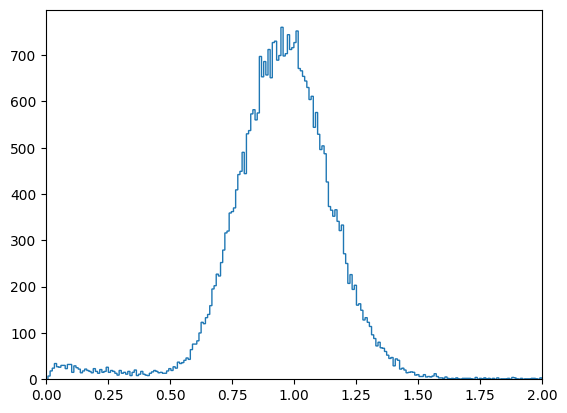

In [224]:
plt.stairs(*np.histogram(range_red,bins=1000))
plt.xlim(0,2)

In [ ]:
# Test for significance: mu=1?

In [ ]:
pgrins_narrow_params.calc_clusters(candidate_matrix)

Calculating distance matrix
Clustering
Getting clusters


100%|██████████| 3327/3327 [00:04<00:00, 771.82it/s]


Calculating silhouette scores


  0%|          | 1/3326 [01:14<68:39:03, 74.33s/it]

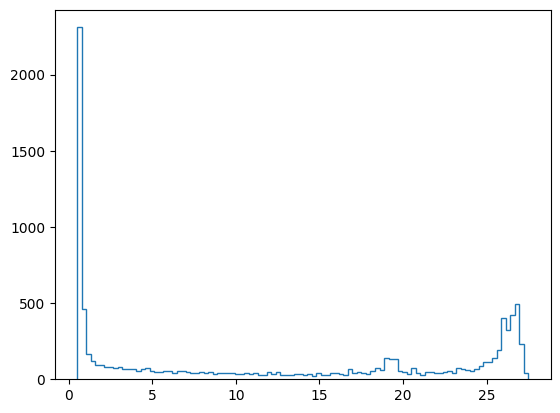

In [36]:
gmse_list = [mean_squared_error(np.asarray(Grins_matrix_1k[i,:]),np.asarray(adata_mean)) for i in range(Grins_matrix_1k.shape[0])]
gtt = np.histogram(gmse_list,bins=100)
plt.stairs(gtt[0],gtt[1])

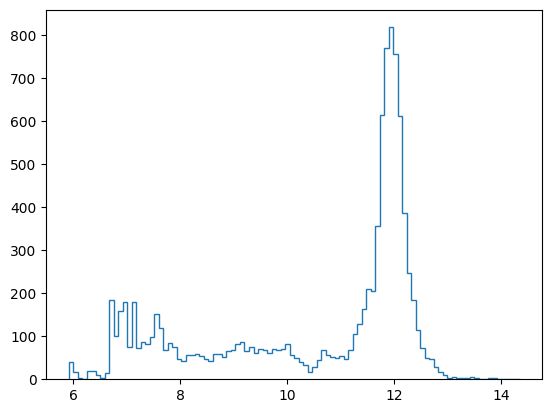

In [28]:
gmse_list = [mean_squared_error(np.asarray(grins_matrix_1k[i,:]),np.asarray(adata_mean)) for i in range(grins_matrix_1k.shape[0])]
gtt = np.histogram(gmse_list,bins=100)
plt.stairs(gtt[0],gtt[1])

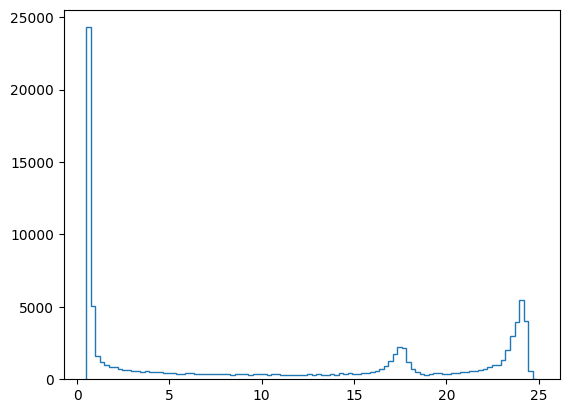

In [6]:
gmse_list = [mean_squared_error(np.asarray(grins_matrix[i,:]),np.asarray(adata_mean)) for i in range(grins_matrix.shape[0])]
gtt = np.histogram(gmse_list,bins=100)
plt.stairs(gtt[0],gtt[1])

In [59]:
gsubset = grins_matrix[np.array(gmse_list)<2.5]
gsubset_mean = np.mean(gsubset,axis=0)

In [78]:
np.mean(mse_list)

np.float64(0.14857812324170797)

In [132]:
adata_score_mean = np.mean(acos_list)
adata_score_sd = np.sqrt(np.var(acos_list))
adata_score_mad = np.median(np.abs(acos_list-adata_score_mean))
adata_score_mean-10*adata_score_mad

np.float32(0.70988685)

np.float64(0.39954616227750506)

In [126]:
times_sd = 20

In [127]:
grins_matrix[(gmse_list>=adata_score_mean-times_sd*adata_score_mad) & (gmse_list<=adata_score_mean+times_sd*adata_score_mad)]

matrix([[1.3751741e-02, 4.1435584e-02, 2.4425944e-02, ..., 1.5832795e-06,
         1.1929353e-02, 5.5827008e-04],
        [1.1218856e-06, 3.6380005e-10, 8.9492909e-07, ..., 1.1910498e-17,
         4.2356327e-10, 4.7694066e-09],
        [1.8489377e-04, 6.1374959e-03, 1.1517593e-03, ..., 3.3849062e-08,
         1.3041003e-05, 2.6573291e-05],
        ...,
        [1.5136130e-01, 9.2741698e-02, 6.6122949e-02, ..., 5.1005391e-06,
         1.7573440e-02, 4.3034344e-03],
        [6.4308576e-02, 4.4755615e-02, 1.4762846e-01, ..., 5.8366105e-08,
         5.3764007e-04, 1.7370932e-03],
        [2.0352448e-03, 2.7630509e-07, 1.1128180e-03, ..., 3.5532981e-08,
         1.8977284e-05, 6.7572282e-06]], shape=(867, 4022), dtype=float32)

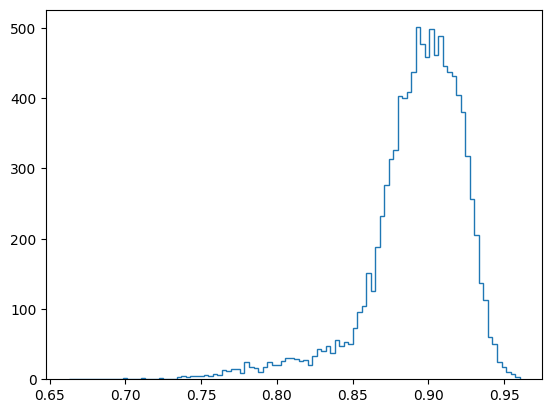

In [130]:
acos_list = [cosine_similarity(np.asarray(adata_matrix[i,:]),np.asarray(adata_mean)).T[0][0] for i in range(adata_matrix.shape[0])]
adata_hist = np.histogram(acos_list,bins=100)
plt.stairs(adata_hist[0],adata_hist[1])

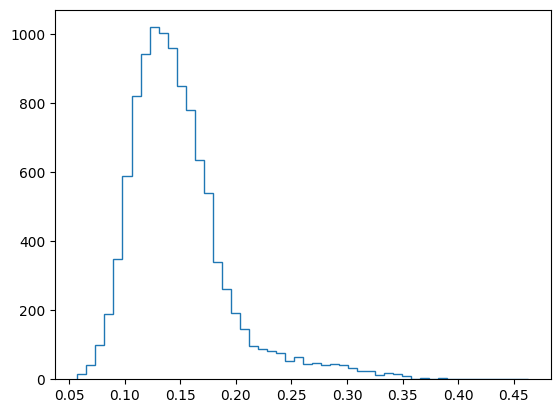

In [ ]:
mse_list = [mean_squared_error(np.asarray(adata_matrix[i,:]),np.asarray(adata_mean)) for i in range(adata_matrix.shape[0])]
adata_hist = np.histogram(mse_list,bins=100)
plt.stairs(adata_hist[0],adata_hist[1])

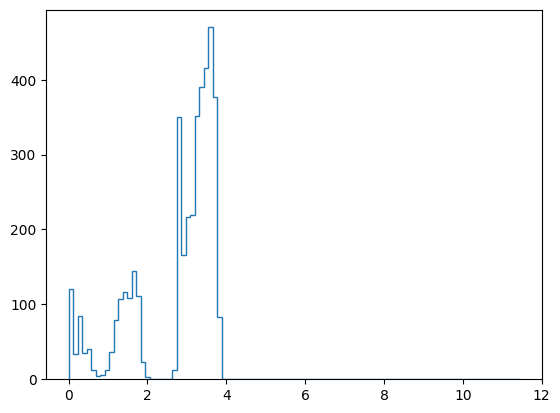

In [35]:
plt.stairs(*np.histogram(np.mean(Grins_matrix_1k,axis=0),bins=100))

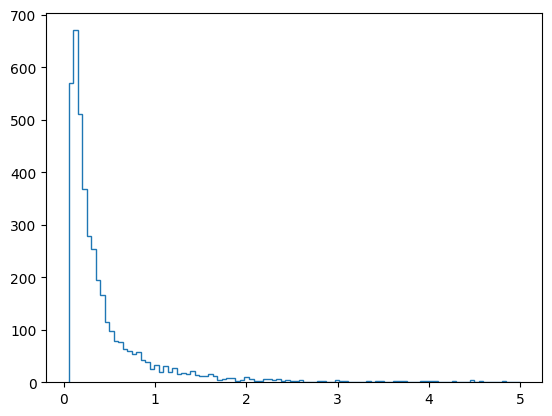

In [32]:
plt.stairs(*np.histogram(np.mean(adata_matrix,axis=0),bins=100))

# Actual clustering:

In [2]:
X = [[0, 0], [0, 1], [1, 0],
     [0, 4], [0, 3], [1, 4],
     [4, 0], [3, 0], [4, 1],
     [4, 4], [3, 4], [4, 3]]
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
X.shape

(150, 4)

In [4]:
grins_data = sc.read_h5ad(f"Data/Projects/Keggoro/perturb_norm.h5ad")

In [5]:
adata = sc.read_h5ad(f"Data/Experimental/Norman19/perturb_subset_Keggoro.h5ad")

In [45]:
rep_data = sc.read_h5ad(f"Data/Experimental/Replogle22/perturb_subset_Keggoro.h5ad")

In [31]:
adata=adata[:,adata.var["pct_dropout_by_counts"]<90]
grins_data=grins_data[:,grins_data.var["pct_dropout_by_counts"]<90]
common_genes = list(set(adata.var_names) & set(grins_data.var_names))
adata = adata[:,common_genes]
grins_data = grins_data[:,common_genes]

In [6]:
grins_matrix = grins_data[grins_data.obs["InitCondNum"]<=10].layers["log1p"].todense()

In [ ]:
# Get distance matrix
# Shape: no. cells (init_conds) x no. cells
# Zsquare = squareform(Z) which one is faster?

In [7]:
dist = pdist(grins_matrix)

In [8]:
dist_matrix = squareform(dist)

In [9]:
# Average linkage clustering (also done in paper)
Z = average(dist)
# Column 0 and 1 contain cluster indices merged in that row
# Column 2 contains the height of the new cluster
# Column 3 contains the size of the new cluster

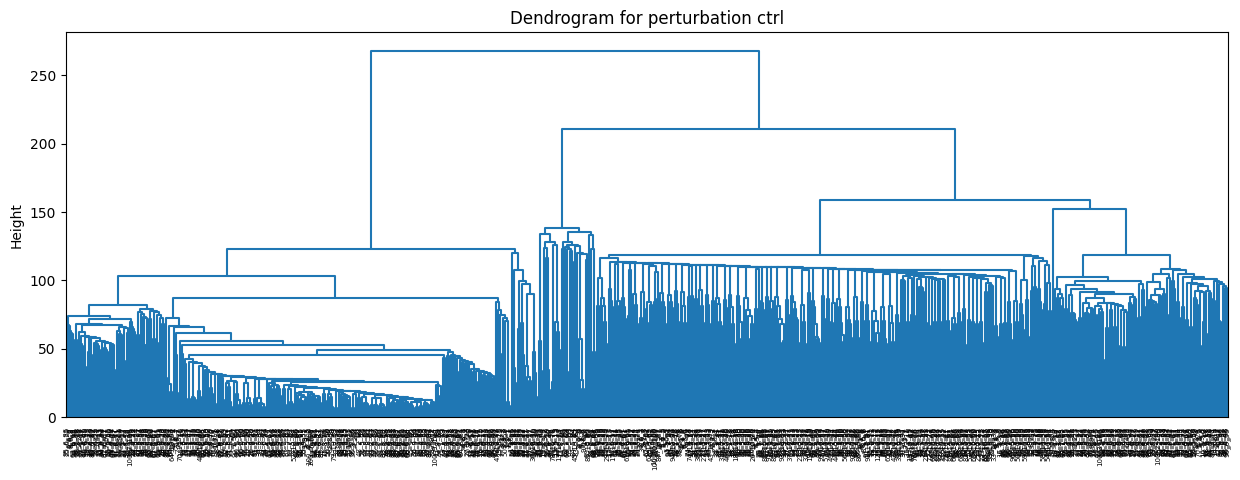

In [10]:
pert = "ctrl"
fig, ax = plt.subplots(figsize=(15,5))
dendrogram(Z,color_threshold=1,labels=grins_data.obs_names[:1000],truncate_mode="lastp",p=900)
ax.set_title(f"Dendrogram for perturbation {pert}")
ax.set_ylabel("Height")
fig.show()

In [11]:
# Get all possible clusterings (N x N matrix)
clusterings = np.empty((0,dist_matrix.shape[0]),int)
heights = np.unique(np.round(Z[:,2]-1e-5,decimals=5)) # Since they are rounded to 5 decimals, subtracting 1e-5 makes them unique(?)
for height in heights:
    clustering = fcluster(Z,t=height,criterion="distance")
    clusterings = np.append(clusterings,[clustering],axis=0)
if len(np.unique(clusterings[0])) == dist_matrix.shape[0]:
    heights = heights[1:]
    clusterings = clusterings[1:]
if len(np.unique(clusterings[-1])) == 1:
    heights = heights[:-1]
    clusterings = clusterings[:-1]

999
998
997
996
995
994
993
992
991
990
989
988
987
986
985
984
983
982
981
980
979
978
977
976
975
974
973
972
971
970
969
968
967
966
965
964
963
962
961
960
959
958
957
956
955
954
953
952
951
950
949
948
947
946
945
944
943
942
941
940
939
938
937
936
935
934
933
932
931
930
929
928
927
926
925
924
923
922
921
920
919
918
917
916
915
914
913
912
911
910
909
908
907
906
905
904
903
902
901
900
899
898
897
896
895
894
893
892
891
890
889
888
887
886
885
884
883
882
881
880
879
878
877
876
875
874
873
872
871
870
869
868
867
866
865
864
863
862
861
860
859
858
857
856
855
854
853
852
851
850
849
848
847
846
845
844
843
842
841
840
839
838
837
836
835
834
833
832
831
830
829
828
827
826
825
824
823
822
821
820
819
818
817
816
815
814
813
812
811
810
809
808
807
806
805
804
803
802
801
800
799
798
797
796
795
794
793
792
791
790
789
788
787
786
785
784
783
782
781
780
779
778
777
776
775
774
773
772
771
770
769
768
767
766
765
764
763
762
761
760
759
758
757
756
755
754
753
752
751
750


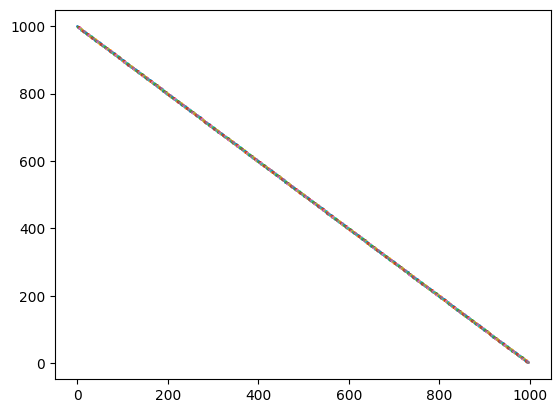

In [12]:
for i in range(clusterings.shape[0]):

    plt.scatter(i,len(np.unique(clusterings[i,:])),s=1)
    print(len(np.unique(clusterings[i,:])))
plt.show()

In [13]:
no_processes = 10
from multiprocessing import Pool
def calc_silhouette_score(clustering):
    global dist_matrix
    #unique, counts = np.unique(clustering, return_counts=True)
    return silhouette_score(dist_matrix,clustering)#/counts

In [14]:
# Calculate the silhouette scores:
#for i in tqdm(range(clusterings.shape[0])):
with Pool(processes=no_processes) as pool:
    sil_scores = pool.map(calc_silhouette_score,clusterings)
pool.close()

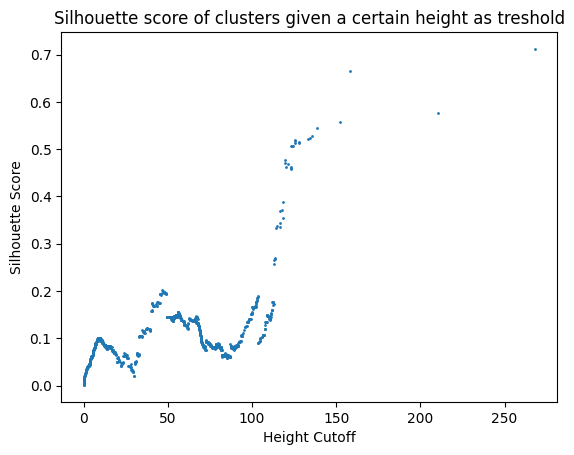

In [15]:
fig, ax = plt.subplots()
ax.scatter(heights,sil_scores,s=1)
ax.set_title("Silhouette score of clusters given a certain height as treshold")
ax.set_ylabel("Silhouette Score")
ax.set_xlabel("Height Cutoff")
fig.savefig("Test.png")
plt.show()

In [21]:
from scipy.signal import find_peaks

In [22]:
peaks, properties = find_peaks(sil_scores,height=0,prominence=0.01,distance=100)

In [23]:
peaks

array([156, 396, 498, 995])

In [24]:
# Get the best clusterings
top_sils = 10
best_clusterings = clusterings[peaks,:]

In [25]:
best_clusterings

array([[287, 446, 286, ..., 659, 522, 400],
       [ 76, 210,  75, ..., 423, 286, 164],
       [ 49, 167,  48, ..., 337, 228, 126],
       [  1,   3,   1, ...,   3,   3,   3]], shape=(4, 1000))

In [26]:
# Get the cluster that is the closest to the control mean in some way:
adata_mean = np.mean(adata.layers["log1p"],axis=0)
best_score_total = 0
best_cluster_total = None # Will have shape [index in best_clusterings with highest score, cluster label within that clustering with the highest score]
for i, clustering in zip(range(len(best_clusterings)),best_clusterings):
    clusters = np.unique(clustering)
    # Get mean gene vector for each cluster
    cluster_means = np.asarray([np.mean(grins_matrix[clustering == cluster],axis=0) for cluster in sorted(np.unique(clustering))])
    # Among the clusters in the current clustering, get the one with the best metric
    metric = []
    for cluster_mean in cluster_means:
        metric.append(cosine_similarity(np.asarray(cluster_mean),np.asarray(adata_mean)).T)# Maybe Pearson Delta?
    #print(metric)
    if np.max(metric)>best_score_total:
        best_cluster_total = [i,clusters[np.argmax(metric)]] 
        best_score_total = np.max(metric)


In [27]:
print(best_cluster_total,best_score_total)

[3, np.int64(3)] 0.5609614


In [28]:
best_cluster_rows = best_clusterings[best_cluster_total[0]]==best_cluster_total[1]

In [29]:
best_cluster_rows

array([False,  True, False, False,  True,  True, False,  True, False,
       False, False, False, False, False, False, False,  True,  True,
       False, False, False, False,  True,  True, False, False,  True,
       False,  True, False,  True, False, False, False, False, False,
       False,  True, False,  True, False,  True,  True,  True,  True,
        True, False, False,  True, False, False, False, False,  True,
       False,  True, False,  True,  True, False, False, False, False,
       False,  True, False, False, False, False, False,  True, False,
       False, False, False, False, False,  True, False, False, False,
        True, False, False,  True, False, False,  True, False, False,
        True,  True,  True,  True, False, False,  True, False,  True,
       False, False, False,  True, False,  True,  True, False,  True,
       False, False, False, False, False, False, False, False,  True,
        True,  True, False, False, False,  True,  True, False,  True,
        True, False,

In [ ]:
best_cluster_indices = list(grins_data[:1000].obs_names[best_cluster_rows])

In [31]:
best_cluster_indices

Index(['2_1_2', '5_1_5', '6_1_6', '8_1_8', '17_1_17', '18_1_18', '23_1_23',
       '24_1_24', '27_1_27', '29_1_29',
       ...
       '88_10_88', '91_10_91', '92_10_92', '93_10_93', '94_10_94', '96_10_96',
       '97_10_97', '98_10_98', '99_10_99', '100_10_100'],
      dtype='object', length=353)

In [ ]:
best_cluster_params = (int(index.split("_")[1]) for index in best_cluster_indices)
best_cluster_ics = (int(index.split("_")[2]) for index in best_cluster_indices)

In [ ]:
with open ("Data/Projects/sKeggoro_abcd/ctrl_best_cluster_indices.pickle","wb") as handle:
    pickle.dump(best_cluster_indices, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
params_sinks = pd.read_parquet("Data/SimulResults_Racipe/Keggoro/001/Keggoro_params_001_sinks_ctrl.parquet")

In [ ]:
params_nonsinks = pd.read_parquet("Data/SimulResults_Racipe/Keggoro/001/Keggoro_params_001_ctrl.parquet")

In [ ]:
ics_nonsinks = pd.read_parquet("Data/SimulResults_Racipe/Keggoro/001/Keggoro_init_conds_001_ctrl.parquet")

In [9]:
ics_nonsinks

,A2M,ABCA1,ABL1,ACACB,ACE,ACE2,ACHE,ACP1,ACTB,ACTC1,...,ZNF750,ZNF76,ZNF766,ZNF83,ZNF92,ZNFX1,ZNRF3,ZYX,ZZZ3,InitCondNum
0,42.587767,37.648042,27.644170,81.216435,83.110840,47.610281,29.300525,12.694088,84.870975,11.193313,...,13.112114,37.989622,70.146293,6.339382,47.786140,80.703166,79.985025,62.346548,34.271469,1
1,58.521961,55.188799,99.005896,43.201982,29.809452,87.125421,97.571191,71.665617,26.186578,68.748552,...,74.174301,89.352705,3.409099,64.533395,77.118351,12.625360,12.927451,31.895152,95.362820,2
2,92.301399,19.218520,10.163053,58.268257,11.071297,63.462590,21.461952,75.254471,14.522955,82.030871,...,94.232787,1.056642,82.497942,46.381692,22.449679,73.666659,67.813187,15.422345,21.871414,3
3,8.401358,99.141839,68.376360,22.020427,52.104372,3.982923,52.238980,41.418928,73.398034,40.015002,...,33.267093,73.686003,40.557528,86.414247,54.888282,42.744467,49.794896,95.375370,59.761953,4
4,22.769421,8.334786,78.699644,5.079798,66.565949,34.468764,9.827998,93.464902,1.823238,57.873713,...,78.075489,61.524611,51.728395,25.768047,95.813591,21.444321,56.026341,4.567384,11.156846,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,38.572201,80.050784,42.613307,99.887667,57.520229,88.970666,73.344011,50.809250,37.943362,66.360721,...,63.716625,69.029826,72.270068,67.749297,94.182100,29.422463,82.308019,16.278884,50.113615,96
96,40.013970,38.548397,15.926161,55.943982,28.958821,78.627019,8.249186,66.738762,72.472011,5.709849,...,44.860707,58.102624,96.906225,7.106875,28.521050,97.352001,73.807201,49.400949,43.720525,97
97,61.265195,70.518592,62.513739,18.158724,83.904140,43.747329,63.709795,1.573737,13.787225,72.649061,...,82.617245,16.651711,26.922706,65.312966,98.075212,16.929809,43.800612,67.675236,80.064833,98
98,88.977909,7.478000,46.555720,83.528265,52.852636,7.852815,44.109833,47.312679,26.822630,78.342026,...,62.556494,79.956846,59.611243,47.161458,4.345049,55.468681,86.365722,77.861972,6.234876,99


In [ ]:
ctrl_min_nonsinks, ctrl_max_nonsinks = pd.min(params_nonsinks[:-1],axis=0), pd.max(params_nonsinks[:-1],axis=0)
ctrl_min_sinks, ctrl_max_sinks = pd.min(params_sinks[:-1],axis=0), pd.max(params_sinks[:-1],axis=0)
ctrl_min_ics, ctrl_max_ics = pd.min(ics_nonsinks[:-1],axis=0), pd.max(ics_nonsinks[:-1],axis=0)

In [ ]:
params_nonsinks = params_nonsinks[params_nonsinks["ParamNum"].isin(best_cluster_params)]
params_sinks = params_sinks[params_sinks["ParamNum"].isin(best_cluster_params)]
ics_nonsinks = ics_nonsinks[ics_nonsinks["ParamNum"].isin(best_cluster_ics)]

In [ ]:
# First idea: simply take min/max of each of them and turn these into prange_min/max etc.
# Before that: plot how they actually are distributed (at least for some params/ics)
# Also plot how big the sampled range would become, esp compared to before

In [ ]:
pert_min_nonsinks, pert_max_nonsinks = pd.min(params_nonsinks[:-1],axis=0), pd.max(params_nonsinks[:-1],axis=0)
pert_min_sinks, pert_max_sinks = pd.min(params_sinks[:-1],axis=0), pd.max(params_sinks[:-1],axis=0)
pert_min_ics, pert_max_ics = pd.min(ics_nonsinks[:-1],axis=0), pd.max(ics_nonsinks[:-1],axis=0)

In [ ]:
narrowing_nonsinks = 1 if pert_max_nonsinks == pert_min_nonsinks else (ctrl_max_nonsinks-ctrl_min_nonsinks)/(pert_max_nonsinks-pert_min_nonsinks)
narrowing_sinks = 1 if pert_max_sinks == pert_min_sinks else (ctrl_max_sinks-ctrl_min_sinks)/(pert_max_sinks-pert_min_sinks)
narrowing_ics = 1 if pert_max_ics == pert_min_ics else (ctrl_max_ics-ctrl_min_ics)/(pert_max_ics-pert_min_ics)

In [ ]:
nonsink_prange_df = pd.DataFrame({"Parameter":list(params_nonsinks.columns)[:-1],"Minimum":pd.Series(nonsink_prange_min),"Maximum":pd.Series(nonsink_prange_max),"Sampling":"Uniform"})
sink_prange_df = pd.DataFrame({"Parameter":list(params_sinks.columns)[:-1],"Minimum":pd.Series(sink_prange_min),"Maximum":pd.Series(sink_prange_max),"Sampling":"Uniform"})
irange_df = pd.DataFrame({"Parameter":list(ics_nonsinks.columns)[:-1],"Minimum":pd.Series(irange_min),"Maximum":pd.Series(irange_max)})

In [ ]:
# Save .csv with shape Parameter/InitCond | Minimum | Maximum | Sampling (\t) -> Uniform for Params
sim_dir = f"Data/SimulResults_Racipe/{grn_file}"
for replicate in range(1, num_replicates+1):
    nonsink_prange_df.to_csv(f"{sim_dir}/{rep:03}/{grn_file}_ic_range_{rep:03}_pert.csv",sep="\t",index=False)
    sink_prange_df.to_csv(f"{sim_dir}/{rep:03}/{grn_file}_ic_range_{rep:03}_sinks_pert.csv",sep="\t",index=False)
    irange_df.to_csv(f"{sim_dir}/{rep:03}/{grn_file}_ic_range_{rep:03}_pert.csv",sep="\t",index=False)